In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('features_v2_final.csv')

In [2]:
X = df.drop(columns=['yield_log1p']) 
y = df['yield_log1p']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Split ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Data Split ---
X_train shape: (12922, 56)
X_test shape: (3231, 56)
y_train shape: (12922,)
y_test shape: (3231,)



--- Training Baseline Random Forest Regressor ---
Baseline model trained.

--- Evaluating Baseline Model ---
Baseline RMSE (log1p scale): 0.1331
Baseline R-squared (R²):     0.9771


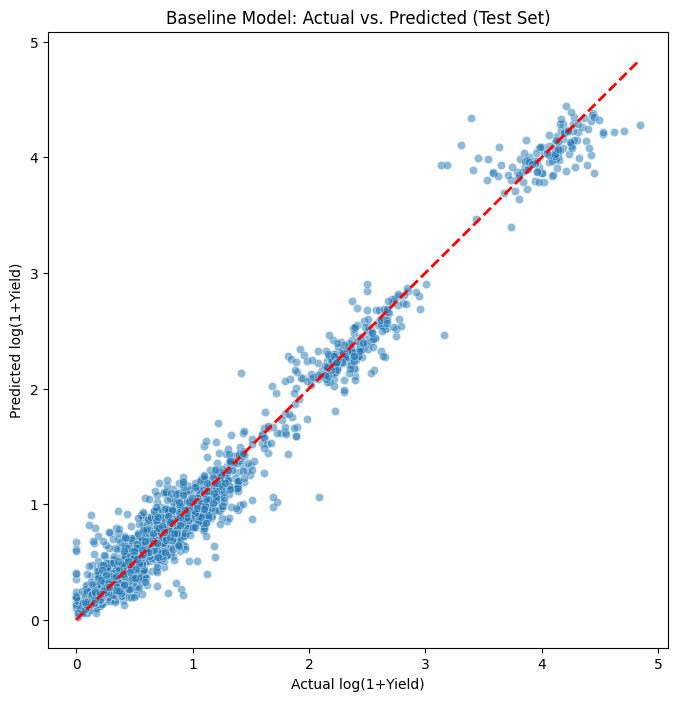

In [4]:
print("\n--- Training Baseline Random Forest Regressor ---")
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Use all CPU cores

rf_baseline.fit(X_train, y_train)
print("Baseline model trained.")



print("\n--- Evaluating Baseline Model ---")
y_pred_baseline = rf_baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline RMSE (log1p scale): {rmse_baseline:.4f}")
print(f"Baseline R-squared (R²):     {r2_baseline:.4f}")

# Optional: Visualize predictions vs actuals
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_baseline, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # y=x line
plt.xlabel("Actual log(1+Yield)")
plt.ylabel("Predicted log(1+Yield)")
plt.title("Baseline Model: Actual vs. Predicted (Test Set)")
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming rf_baseline is your trained RandomForestRegressor from Task 6
# Assuming X_train is available from Task 6

importances = rf_baseline.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easier handling
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("--- Top 20 Feature Importances ---")
print(feature_importance_df.head(20))

--- Top 20 Feature Importances ---
                     feature  importance
55              crop_encoded    0.898320
3            total_precip_mm    0.043752
0                       year    0.017982
1                       area    0.009783
2                 avg_temp_c    0.007581
49             season_Autumn    0.003367
6                     mean_p    0.002374
52             season_Summer    0.000832
4                    mean_ph    0.000766
53         season_Whole Year    0.000711
51               season_Rabi    0.000710
41      district_nabarangpur    0.000665
14  soil_mixed_red_and_black    0.000608
31          district_jajapur    0.000603
7                     mean_k    0.000595
5                     mean_n    0.000568
43          district_nuapada    0.000510
39       district_malkangiri    0.000507
12     soil_deltaic_alluvial    0.000486
10         soil_brown_forest    0.000441


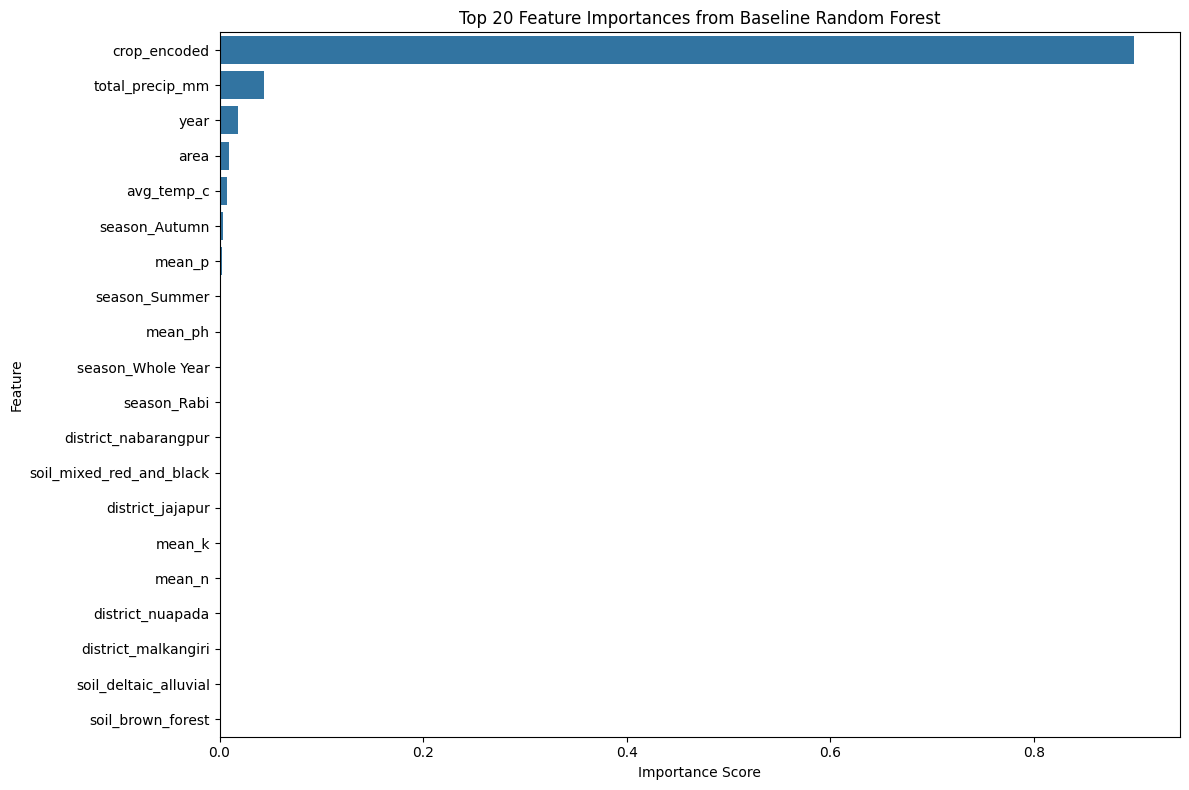

In [6]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Baseline Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()